# Siddak Marwaha
# CMSE 381 HW7

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

### Q 8.4.4:

ATTACHED PICTURE

### Q 8.4.9:

a)

In [2]:
# Load data
OJ_data = pd.read_csv("OJ.csv") # Load your dataset

# Create training and test sets
train_data, test_data = train_test_split(OJ_data, train_size=800, random_state=42)

# Separate features and target
X_train = train_data.drop(columns=['Purchase'])
y_train = train_data['Purchase']
X_test = test_data.drop(columns=['Purchase'])
y_test = test_data['Purchase']

b)

In [3]:
# Convert categorical variables to numeric
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Fit decision tree
tree_clf = DecisionTreeClassifier(random_state=12)
tree_clf.fit(X_train, y_train)

# Training error rate
train_predictions = tree_clf.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)
train_error_rate = 1 - train_accuracy
print("Training Error Rate:", train_error_rate)


Training Error Rate: 0.0


c)

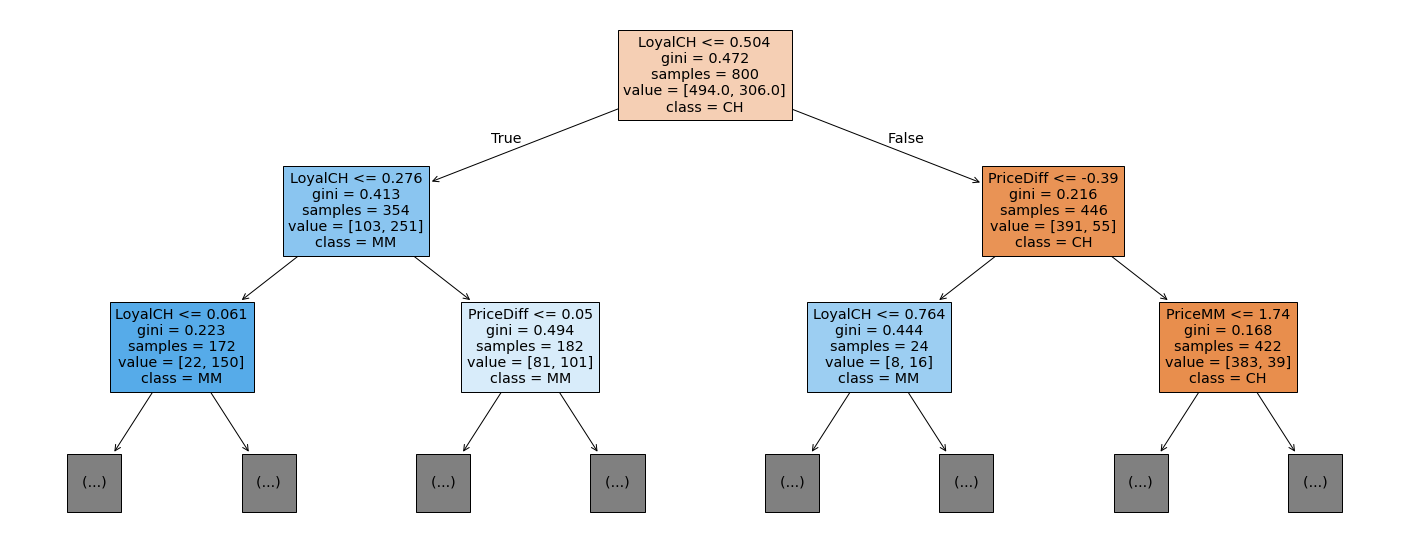

Number of terminal nodes: 143


In [4]:
# Plot the decision tree
plt.figure(figsize=(25, 10))
tree.plot_tree(tree_clf, filled=True, feature_names=X_train.columns, class_names=tree_clf.classes_, max_depth=2)
plt.show()

# Count the terminal nodes
n_terminal_nodes = tree_clf.get_n_leaves()
print("Number of terminal nodes:", n_terminal_nodes)


d)

In [5]:
# Print a text summary of the tree
print(export_text(tree_clf, feature_names=list(X_train.columns)))


|--- LoyalCH <= 0.50
|   |--- LoyalCH <= 0.28
|   |   |--- LoyalCH <= 0.06
|   |   |   |--- Unnamed: 0 <= 954.50
|   |   |   |   |--- class: MM
|   |   |   |--- Unnamed: 0 >  954.50
|   |   |   |   |--- class: CH
|   |   |--- LoyalCH >  0.06
|   |   |   |--- LoyalCH <= 0.21
|   |   |   |   |--- Unnamed: 0 <= 647.50
|   |   |   |   |   |--- Unnamed: 0 <= 559.50
|   |   |   |   |   |   |--- StoreID <= 3.50
|   |   |   |   |   |   |   |--- PriceDiff <= 0.32
|   |   |   |   |   |   |   |   |--- class: MM
|   |   |   |   |   |   |   |--- PriceDiff >  0.32
|   |   |   |   |   |   |   |   |--- PctDiscCH <= 0.03
|   |   |   |   |   |   |   |   |   |--- class: MM
|   |   |   |   |   |   |   |   |--- PctDiscCH >  0.03
|   |   |   |   |   |   |   |   |   |--- class: CH
|   |   |   |   |   |   |--- StoreID >  3.50
|   |   |   |   |   |   |   |--- Unnamed: 0 <= 352.50
|   |   |   |   |   |   |   |   |--- SalePriceMM <= 1.54
|   |   |   |   |   |   |   |   |   |--- LoyalCH <= 0.16
|   |   |   |   | 

e)

In [6]:
# Predict on test set
test_predictions = tree_clf.predict(X_test)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, test_predictions)
print("Confusion Matrix:\n", conf_matrix)

# Test error rate
test_error_rate = 1 - accuracy_score(y_test, test_predictions)
print("Test Error Rate:", test_error_rate)


Confusion Matrix:
 [[124  35]
 [ 45  66]]
Test Error Rate: 0.2962962962962963


f)

In [7]:
# Perform cross-validation for different tree depths
depths = range(1, 20)
cv_scores = []

for depth in depths:
    temp_tree = DecisionTreeClassifier(max_depth=depth, random_state=12)
    scores = cross_val_score(temp_tree, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(1 - np.mean(scores))  # Convert accuracy to error rate

# Optimal tree size
optimal_depth = depths[np.argmin(cv_scores)]
print("CV Scores:", cv_scores)
print("Optimal Tree Depth:", optimal_depth)


CV Scores: [0.2037500000000001, 0.1987500000000001, 0.1775, 0.17500000000000004, 0.18625000000000003, 0.19250000000000012, 0.19499999999999995, 0.21125000000000005, 0.20125000000000004, 0.21625000000000005, 0.21875, 0.21875, 0.21375, 0.21375, 0.21500000000000008, 0.21125000000000005, 0.21624999999999994, 0.21624999999999994, 0.21624999999999994]
Optimal Tree Depth: 4


g)

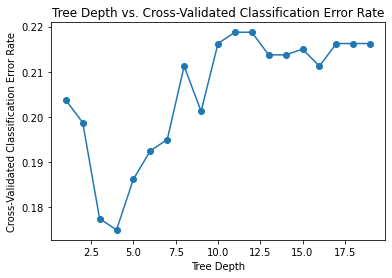

In [8]:
# Plotting
plt.plot(depths, cv_scores, marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("Cross-Validated Classification Error Rate")
plt.title("Tree Depth vs. Cross-Validated Classification Error Rate")
plt.show()


h)

From the plot above, the optimal tree size is 4. It's the depth with the lowest cross-validated error rate.

**Added Part:**

~/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py:615: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


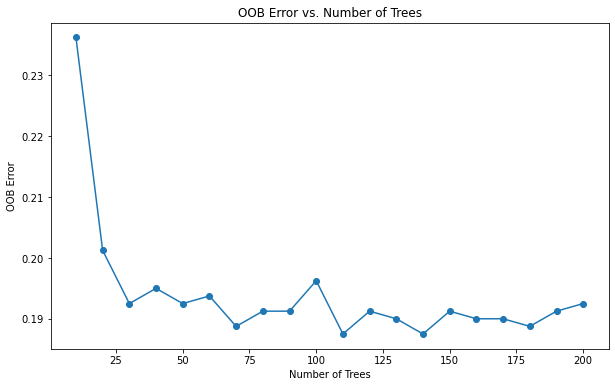

In [9]:
# Evaluate model performance with varying numbers of estimators
n_tree_list = np.arange(10, 201, 10)
oob_errors = []

for n_trees in n_tree_list:
    random_forest_model = RandomForestClassifier(n_estimators=n_trees, max_features='sqrt', oob_score=True, random_state=42)
    random_forest_model.fit(X_train, y_train)
    oob_errors.append(1 - random_forest_model.oob_score_)

# Plotting OOB error against number of trees
plt.figure(figsize=(10, 6))
plt.plot(n_tree_list, oob_errors, marker='o')
plt.title('OOB Error vs. Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('OOB Error')
plt.show()


- n_estimators: 70 trees is a value after which OOB error stabilizes.
- max_features: Using sqrt(p) for classification tasks to reduce correlation between trees while retaining model accuracy.